Current working directory set to: c:\Users\choug\OneDrive\Documents\business-kpi-anomaly-monitor
Cleaned file not found! Automatically generating it now...
✅ Data successfully cleaned and saved!
Generating charts...


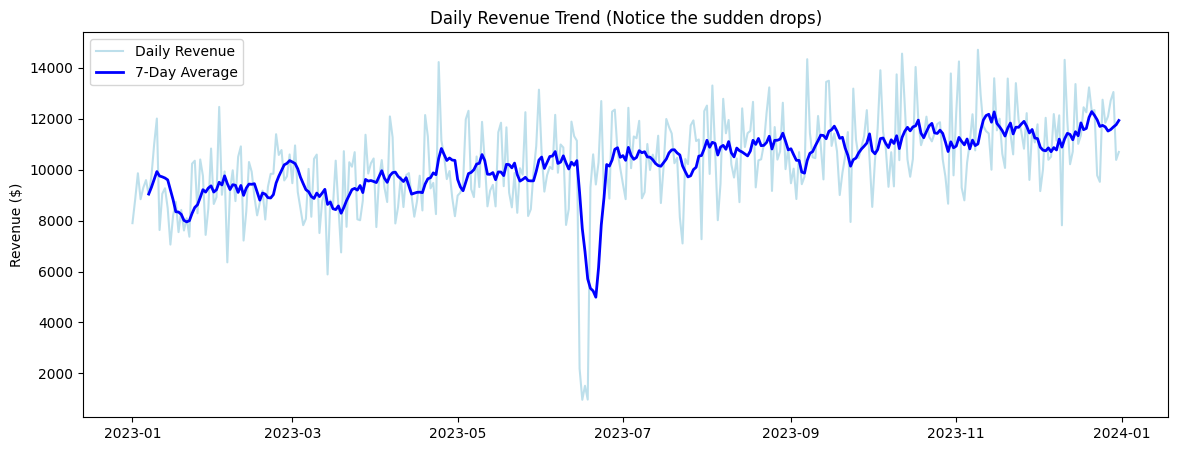

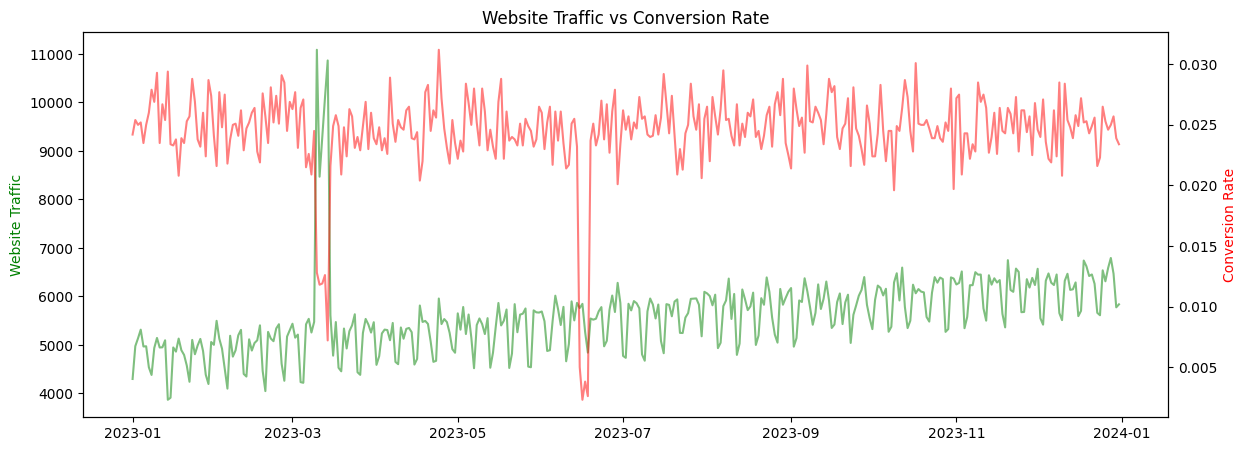

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Force the notebook to operate from the main project folder
if os.getcwd().endswith('notebooks'):
    os.chdir('..')
    
print(f"Current working directory set to: {os.getcwd()}")

raw_path = 'data/raw/synthetic_business_data.csv'
clean_path = 'data/processed/cleaned_business_data.csv'

# 2. Automatically clean the data if the file is missing
if not os.path.exists(clean_path):
    print("Cleaned file not found! Automatically generating it now...")
    # Load raw data
    df_raw = pd.read_csv(raw_path)
    # Fill missing values
    df_raw = df_raw.ffill()
    # Fix dates
    df_raw['date'] = pd.to_datetime(df_raw['date'])
    # Remove negative anomalies (data quality check)
    df_raw = df_raw[(df_raw['revenue'] >= 0) & (df_raw['orders'] >= 0)]
    df_raw = df_raw.sort_values('date').reset_index(drop=True)
    
    # Save the cleaned data to the correct location
    os.makedirs(os.path.dirname(clean_path), exist_ok=True)
    df_raw.to_csv(clean_path, index=False)
    print("✅ Data successfully cleaned and saved!")
else:
    print("✅ Found existing cleaned data file.")

# 3. Load the data and generate the charts
print("Generating charts...")
df = pd.read_csv(clean_path)
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

# Plot 1: Daily Revenue Trend
plt.figure(figsize=(14, 5))
plt.plot(df.index, df['revenue'], label='Daily Revenue', color='lightblue', alpha=0.8)
plt.plot(df.index, df['revenue'].rolling(7).mean(), label='7-Day Average', color='blue', linewidth=2)
plt.title('Daily Revenue Trend (Notice the sudden drops)')
plt.ylabel('Revenue ($)')
plt.legend()
plt.show()

# Plot 2: Traffic vs Conversion Rate
fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()
ax1.plot(df.index, df['website_traffic'], color='green', label='Traffic', alpha=0.5)
ax2.plot(df.index, df['conversion_rate'], color='red', label='Conversion Rate', alpha=0.5)
ax1.set_ylabel('Website Traffic', color='green')
ax2.set_ylabel('Conversion Rate', color='red')
plt.title('Website Traffic vs Conversion Rate')
plt.show()